### **Vasicek Model**
One of the most fundamental models for interest rate dynamics.

#### **Mathematical Term:**
##### $dr_t = \theta (\mu - r_t) dt + \sigma dW_t$

#### **Numerical Discretisation:**
$r_{t+\Delta t} = r_t + \theta (\mu - r_t) \Delta t + \sigma \sqrt{\Delta t} \epsilon_t$

### Read the data

In [1]:
treasury <- read.csv("../../../data/TreasuryHistory.csv")
treasury$Date <- as.Date(treasury$Date)
rownames(treasury) <- NULL

### We will focus on the 10-year tenor

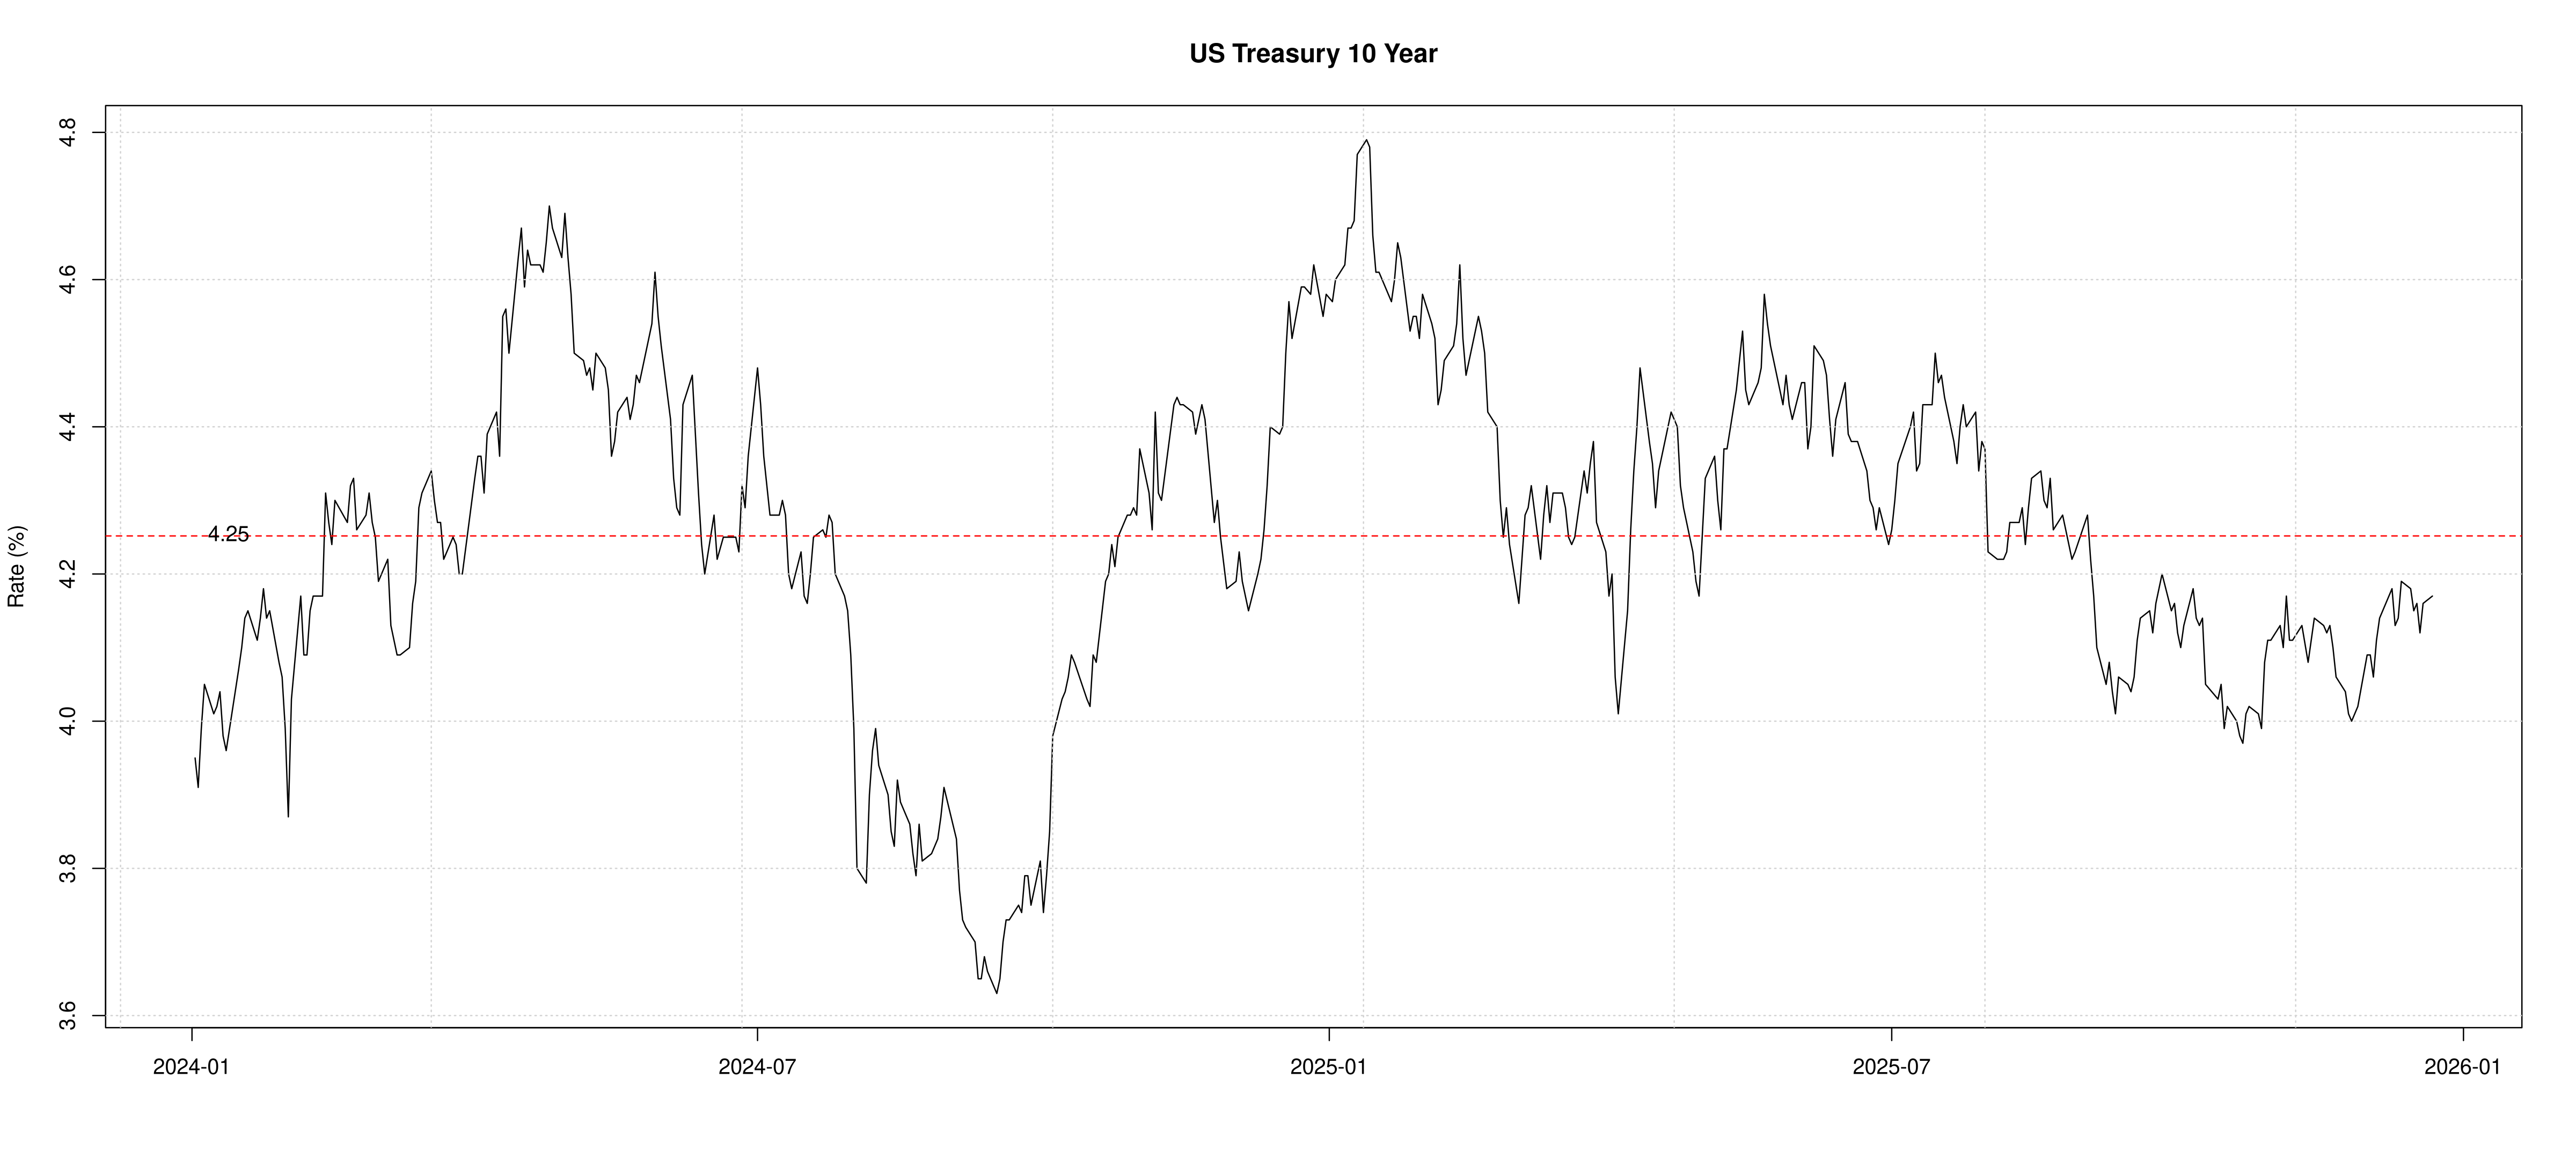

In [2]:
tenor <- "TSY10YR"
df    <- treasury[treasury$Date >= as.Date("2024-01-01"), c("Date", tenor)]
colnames(df) <- c("Date", "rate")

plot(df$Date, df$rate, type = "l",
     main = "US Treasury 10 Year", xlab = "", ylab = "Rate (%)")
abline(h = mean(df$rate, na.rm = TRUE), col = "red", lty = 2)
text(min(df$Date), mean(df$rate, na.rm = TRUE),
     labels = sprintf("%.2f", mean(df$rate, na.rm = TRUE)), pos = 4)
grid()

### Estimate μ, σ and θ
- **Method 1:** μ and σ from frequentist methods; θ from OLS without intercept
- **Method 2:** All three estimated via OLS with intercept

### Method 1
$r_t - r_{t-1} = \theta (\mu - r_{t-1}) + \epsilon$

In [3]:
temp       <- df
temp$rate  <- zoo::na.locf(temp$rate)   # forward-fill NAs
temp$rate  <- temp$rate / 100
temp$diff  <- c(NA, diff(temp$rate))
temp$mu_lag1 <- mean(temp$rate, na.rm = TRUE) - dplyr::lag(temp$rate)

temp_clean <- na.omit(temp[, c("diff", "mu_lag1")])
result1    <- lm(diff ~ mu_lag1 - 1, data = temp_clean)  # no intercept
summary(result1)


Call:
lm(formula = diff ~ mu_lag1 - 1, data = temp_clean)

Residuals:
       Min         1Q     Median         3Q        Max 
-0.0019792 -0.0003733 -0.0000096  0.0003451  0.0019328 

Coefficients:
        Estimate Std. Error t value Pr(>|t|)   
mu_lag1   0.0303     0.0107    2.83   0.0049 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.000532 on 491 degrees of freedom
Multiple R-squared:  0.016,	Adjusted R-squared:  0.014 
F-statistic:    8 on 1 and 491 DF,  p-value: 0.00487


In [4]:
mu1    <- mean(temp$rate, na.rm = TRUE)
sigma1 <- sd(temp$rate, na.rm = TRUE)
theta1 <- coef(result1)["mu_lag1"]
cat(sprintf("Method 1 | Mu: %.4f | Sigma: %.4f | Theta: %.4f\n", mu1, sigma1, theta1))

Method 1 | Mu: 0.0425 | Sigma: 0.0022 | Theta: 0.0303


### Method 2
$r_t - r_{t-1} = \theta \mu - \theta r_{t-1} + \epsilon$

In [5]:
temp2      <- df
temp2$rate <- zoo::na.locf(temp2$rate)
temp2$rate <- temp2$rate / 100
temp2$diff <- c(NA, diff(temp2$rate))
temp2$lag1 <- dplyr::lag(temp2$rate)

temp2_clean <- na.omit(temp2[, c("diff", "lag1")])
result2     <- lm(diff ~ lag1, data = temp2_clean)
summary(result2)


Call:
lm(formula = diff ~ lag1, data = temp2_clean)

Residuals:
       Min         1Q     Median         3Q        Max 
-0.0019837 -0.0003778 -0.0000141  0.0003406  0.0019283 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)   
(Intercept)  0.001291   0.000456    2.83   0.0048 **
lag1        -0.030265   0.010709   -2.83   0.0049 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.000533 on 490 degrees of freedom
Multiple R-squared:  0.016,	Adjusted R-squared:  0.014 
F-statistic: 7.99 on 1 and 490 DF,  p-value: 0.00491


In [6]:
theta2         <- -coef(result2)["lag1"]
theta_times_mu <- coef(result2)["(Intercept)"]
mu2            <- theta_times_mu / theta2
sigma2         <- sd(temp2$rate, na.rm = TRUE)
cat(sprintf("Method 2 | Mu: %.4f | Sigma: %.4f | Theta: %.4f\n", mu2, sigma2, theta2))

Method 2 | Mu: 0.0427 | Sigma: 0.0022 | Theta: 0.0303


### Simulation Forecast

In [7]:
vasicek_model <- function(theta, mu, sigma, r0, T_horizon, dt) {
    N     <- as.integer(T_horizon / dt)
    rates <- numeric(N)
    rates[1] <- r0
    for (t in 2:N) {
        dr       <- theta * (mu - rates[t-1]) * dt + sigma * sqrt(dt) * rnorm(1)
        rates[t] <- rates[t-1] + dr
    }
    rates
}

simulate_vasicek_paths <- function(theta, mu, sigma, r0, T_horizon, dt, num_simulations) {
    N   <- as.integer(T_horizon / dt)
    mat <- matrix(NA, nrow = N, ncol = num_simulations)
    for (i in seq_len(num_simulations)) {
        mat[, i] <- vasicek_model(theta, mu, sigma, r0, T_horizon, dt)
    }
    as.data.frame(mat)
}

r0              <- tail(df$rate, 1) / 100
T_horizon       <- 1.0
dt              <- 1 / 252
num_simulations <- 10

simulated_paths <- simulate_vasicek_paths(theta2, mu2, sigma2, r0, T_horizon, dt, num_simulations)

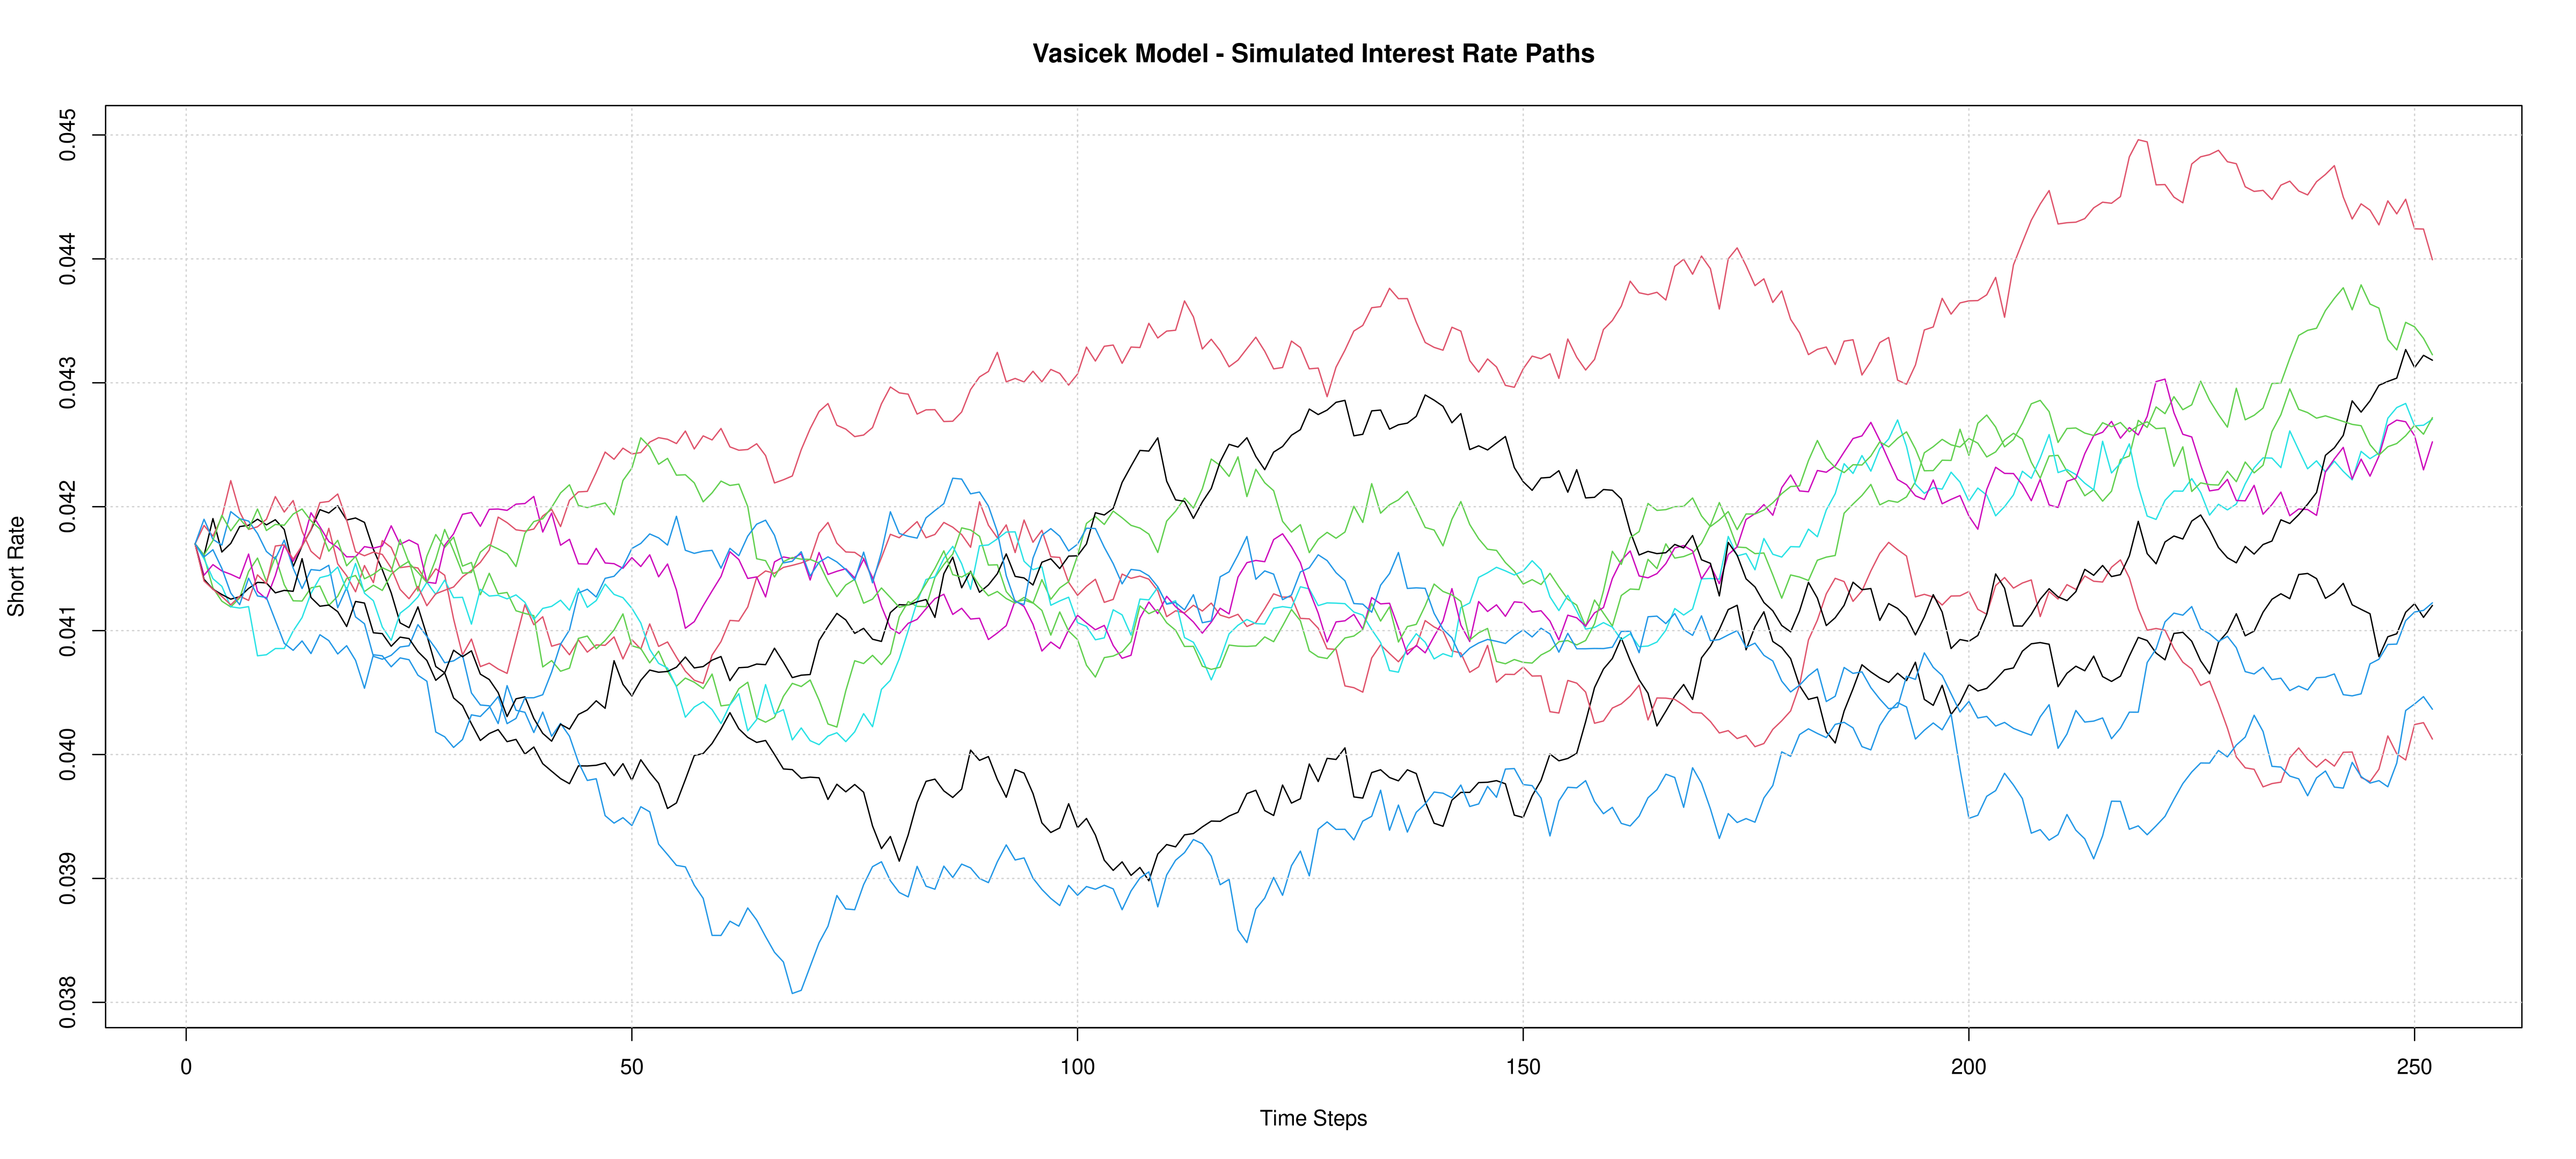

In [8]:
matplot(simulated_paths, type = "l", lty = 1,
        main = "Vasicek Model - Simulated Interest Rate Paths",
        xlab = "Time Steps", ylab = "Short Rate")
grid()

In [9]:
cat("Shape:", nrow(simulated_paths), "x", ncol(simulated_paths), "\n")

Shape: 252 x 10 


### Disadvantages
- **Negative interest rates**: Vasicek allows negative rates, which may be unrealistic
- **Constant volatility**: σ is fixed, not capturing real-world volatility clustering
- **Lack of flexibility**: More advanced models (CIR) address some of these issues